# Medical FAQ Chatbot — Disesuaikan dengan Dataset Medis

## Tujuan
Membangun chatbot pencarian informasi kesehatan yang mengambil jawaban dari dataset FAQ medis yang disediakan. Chatbot mencari pertanyaan paling relevan, menampilkan jawaban sumber, serta menyediakan rujukan sumber/URL jika tersedia.

## Latar belakang
Dataset berbentuk pasangan *question–answer* berbahasa Inggris dengan metadata `question_type`, `focus`, `source`, dan `url`. Karena satu penyakit dapat memiliki beberapa jenis pertanyaan, pencarian perlu mempertimbangkan topik penyakit dan maksud pertanyaan (misalnya symptoms, treatment, causes, atau outlook).

## Manfaat dan dampak
Membantu pengguna menemukan informasi edukasi medis yang sudah ada dalam dataset dengan lebih cepat. Sistem ini hanya mengambil informasi dari dataset, bukan mendiagnosis atau memberi rekomendasi perawatan personal.

## Batasan
- Dataset berbahasa Inggris; kueri Bahasa Inggris paling sesuai. Kueri Bahasa Indonesia tidak dijamin cocok.
- Jawaban dibatasi pada isi dataset dan dapat tidak lengkap atau tidak mutakhir.
- Sistem retrieval bukan model diagnosis klinis. Untuk kondisi darurat, hubungi layanan darurat setempat.



## LANGKAH 1 — Instalasi Library


In [ ]:
%pip install -q pandas numpy scikit-learn matplotlib sentence-transformers ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.6 MB/s eta 0:00:00


## LANGKAH 2 — Import Library dan Konfigurasi

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 180)


## LANGKAH 3 — Memuat dan Memahami Dataset



In [ ]:
from pathlib import Path

DATA_PATH = "medical_chatbot_dataset.csv"
if not Path(DATA_PATH).exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = next(iter(uploaded))
    except Exception as e:
        raise FileNotFoundError(
            f"CSV '{DATA_PATH}' tidak ditemukan. Unggah file CSV atau letakkan di direktori kerja."
        ) from e

df = pd.read_csv(DATA_PATH)
required = ["question", "answer", "question_type", "focus"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing}")

# Rapikan nilai teks dan buang baris tanpa pertanyaan/jawaban.
for col in ["question", "answer", "question_type", "focus", "source", "url"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

df = df[(df["question"] != "") & (df["answer"] != "")].drop_duplicates(
    subset=["question", "answer"]
).reset_index(drop=True)

print(f"Jumlah baris setelah pembersihan: {len(df):,}")
print("Kolom:", df.columns.tolist())
print("\nContoh data:")
display(df[["question", "answer", "question_type", "focus", "source"]].head(5))
print("\nJumlah question_type:", df["question_type"].nunique())
print("Jumlah focus unik:", df["focus"].nunique())


Jumlah baris setelah pembersihan: 3,150
Kolom: ['id', 'question', 'answer', 'question_type', 'focus', 'source', 'url']

Contoh data:


,question,answer,question_type,focus,source
0,What is the outlook for Familial Periodic Paralyses ?,The prognosis for the familial periodic paralyses varies. Chronic attacks may result in progressive weakness that persists between attacks. Some cases respond well to treatment...,outlook,Familial Periodic Paralyses,NINDS
1,What is the outlook for Metastatic Squamous Neck Cancer with Occult Primary ?,Certain factors affect prognosis (chance of recovery) and treatment options. The prognosis (chance of recovery) and treatment options depend on the following: - The number and ...,outlook,Metastatic Squamous Neck Cancer with Occult Primary,CancerGov
2,What are the treatments for Dysgraphia ?,Treatment for dysgraphia varies and may include treatment for motor disorders to help control writing movements. Other treatments may address impaired memory or other neurologi...,treatment,Dysgraphia,NINDS
3,what research (or clinical trials) is being done for Transient Ischemic Attack ?,NINDS is the leading supporter of research on stroke and TIA in the U.S. and sponsors studies ranging from clinical trials to investigations of basic biological mechanisms as w...,research,Transient Ischemic Attack,NINDS
4,What is (are) Prostate Cancer ?,"The prostate is a male sex gland, about the size of a large walnut. It is located below the bladder and in front of the rectum. The prostate's main function is to make fluid fo...",information,Prostate Cancer,NIHSeniorHealth



Jumlah question_type: 16
Jumlah focus unik: 1891


## LANGKAH 4 — Preprocessing Teks dan Pemeriksaan Metadata



In [ ]:
def normalize_text(text):
    text = str(text).lower()
    text = text.replace("&", " and ")
    text = re.sub(r"[^a-z0-9'\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["normalized_question"] = df["question"].apply(normalize_text)
df["normalized_focus"] = df["focus"].apply(normalize_text)
df["normalized_type"] = df["question_type"].apply(normalize_text)

# Dokumen indeks memuat pertanyaan + metadata. Jawaban tidak dimasukkan ke indeks
# agar sistem tidak sekadar mencocokkan teks jawaban.
df["search_text"] = (
    df["normalized_question"] + " " +
    df["normalized_focus"] + " " +
    df["normalized_type"].str.replace(" ", " ", regex=False)
).str.strip()

display(df[["question", "normalized_question", "question_type", "focus", "search_text"]].head(8))


,question,normalized_question,question_type,focus,search_text
0,What is the outlook for Familial Periodic Paralyses ?,what is the outlook for familial periodic paralyses,outlook,Familial Periodic Paralyses,what is the outlook for familial periodic paralyses familial periodic paralyses outlook
1,What is the outlook for Metastatic Squamous Neck Cancer with Occult Primary ?,what is the outlook for metastatic squamous neck cancer with occult primary,outlook,Metastatic Squamous Neck Cancer with Occult Primary,what is the outlook for metastatic squamous neck cancer with occult primary metastatic squamous neck cancer with occult primary outlook
2,What are the treatments for Dysgraphia ?,what are the treatments for dysgraphia,treatment,Dysgraphia,what are the treatments for dysgraphia dysgraphia treatment
3,what research (or clinical trials) is being done for Transient Ischemic Attack ?,what research or clinical trials is being done for transient ischemic attack,research,Transient Ischemic Attack,what research or clinical trials is being done for transient ischemic attack transient ischemic attack research
4,What is (are) Prostate Cancer ?,what is are prostate cancer,information,Prostate Cancer,what is are prostate cancer prostate cancer information
5,What is (are) Moles ?,what is are moles,information,Moles,what is are moles moles information
6,What are the symptoms of Childhood Ependymoma ?,what are the symptoms of childhood ependymoma,symptoms,Childhood Ependymoma,what are the symptoms of childhood ependymoma childhood ependymoma symptoms
7,"What is the outlook for Ovarian Epithelial, Fallopian Tube, and Primary Peritoneal Cancer ?",what is the outlook for ovarian epithelial fallopian tube and primary peritoneal cancer,outlook,"Ovarian Epithelial, Fallopian Tube, and Primary Peritoneal Cancer",what is the outlook for ovarian epithelial fallopian tube and primary peritoneal cancer ovarian epithelial fallopian tube and primary peritoneal cancer outlook


## LANGKAH 5 — Mesin Retrieval: Sentence-BERT + TF-IDF + Pencocokan Metadata



In [ ]:
# Buat indeks TF-IDF berbasis kata dan karakter.
word_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=50000, sublinear_tf=True)
char_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1, max_features=60000, sublinear_tf=True)
word_matrix = word_vectorizer.fit_transform(df["search_text"])
char_matrix = char_vectorizer.fit_transform(df["search_text"])

# Muat Sentence-BERT; jika unduhan/model tidak tersedia, lanjutkan dengan fallback TF-IDF.
USE_SBERT = False
sbert_model = None
sbert_embeddings = None
try:
    from sentence_transformers import SentenceTransformer
    sbert_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    sbert_embeddings = sbert_model.encode(
        df["search_text"].tolist(),
        normalize_embeddings=True,
        show_progress_bar=True
    )
    USE_SBERT = True
    print("Sentence-BERT aktif.")
except Exception as e:
    print("Sentence-BERT tidak berhasil dimuat; fallback TF-IDF aktif.")
    print("Detail:", str(e)[:350])

INTENT_KEYWORDS = {
    "symptoms": ["symptom", "symptoms", "sign", "signs", "feel like", "indication"],
    "treatment": ["treatment", "treat", "treated", "therapy", "therapies", "medicine", "medication", "cure"],
    "causes": ["cause", "causes", "caused", "why", "reason"],
    "prevention": ["prevent", "prevention", "reduce risk", "avoid"],
    "outlook": ["outlook", "prognosis", "life expectancy", "recover", "recovery"],
    "diagnosis": ["diagnos", "exam", "exams", "test", "tests", "diagnostic"],
    "inheritance": ["inherit", "inherited", "genetic", "hereditary", "passed down"],
    "susceptibility": ["risk", "susceptible", "prone", "who is at risk"],
    "frequency": ["common", "frequent", "frequency", "how many", "how often", "prevalence"],
    "research": ["research", "clinical trial", "clinical trials", "studies"],
    "information": ["what is", "what are", "define", "definition", "information about"]
}

def detect_intent(query):
    q = normalize_text(query)
    found = [intent for intent, words in INTENT_KEYWORDS.items()
             if any(term in q for term in words)]
    return found

def retrieve(query, top_k=5):
    q = normalize_text(query)
    if not q:
        return pd.DataFrame()

    q_word = word_vectorizer.transform([q])
    q_char = char_vectorizer.transform([q])
    word_scores = cosine_similarity(q_word, word_matrix).ravel()
    char_scores = cosine_similarity(q_char, char_matrix).ravel()

    # Bobot semantic lebih besar bila Sentence-BERT tersedia.
    if USE_SBERT:
        q_emb = sbert_model.encode([query], normalize_embeddings=True)
        semantic_scores = (sbert_embeddings @ q_emb[0]).ravel()
        scores = 0.60 * semantic_scores + 0.25 * word_scores + 0.15 * char_scores
    else:
        semantic_scores = np.zeros(len(df))
        scores = 0.65 * word_scores + 0.35 * char_scores

    # Bonus terbatas untuk intent dan nama focus yang disebut eksplisit.
    intents = detect_intent(query)
    if intents:
        type_norm = df["normalized_type"].to_numpy()
        intent_bonus = np.array([
            1.0 if any(intent in typ or typ in intent for intent in intents) else 0.0
            for typ in type_norm
        ])
        scores = scores + 0.08 * intent_bonus

    q_compact = re.sub(r"[^a-z0-9]", "", q)
    focus_bonus = np.zeros(len(df))
    if q_compact:
        for i, focus in enumerate(df["normalized_focus"]):
            f_compact = re.sub(r"[^a-z0-9]", "", focus)
            if len(f_compact) >= 4 and f_compact in q_compact:
                focus_bonus[i] = 0.18
    scores = scores + focus_bonus

    # Skor final dibatasi ke rentang 0-1 agar mudah dibaca.
    scores = np.clip(scores, 0, 1)
    order = np.argsort(scores)[::-1][:top_k]
    result = df.iloc[order][["question", "answer", "question_type", "focus", "source", "url"]].copy()
    result.insert(0, "score", scores[order])
    result.insert(1, "semantic_score", semantic_scores[order])
    result.insert(2, "word_score", word_scores[order])
    result.insert(3, "char_score", char_scores[order])
    return result.reset_index(drop=True)

print("Mode retrieval:", "Sentence-BERT + TF-IDF" if USE_SBERT else "TF-IDF word + character")
display(retrieve("What are the symptoms of Parkinson's disease?", top_k=5))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/99 [00:00<?, ?it/s]

Sentence-BERT aktif.
Mode retrieval: Sentence-BERT + TF-IDF


,score,semantic_score,word_score,char_score,question,answer,question_type,focus,source,url
0,1.000000,0.877945,0.890771,0.995384,What are the symptoms of Parkinson's Disease ?,"Doctors may prescribe a variety of medications to treat the non-motor symptoms of Parkinson's disease, such as depression and anxiety. Hallucinations, delusions, and other psyc...",symptoms,Parkinson's Disease,NIHSeniorHealth,http://nihseniorhealth.gov/parkinsonsdisease/toc.html
1,0.903809,0.633218,0.530268,0.875408,What is (are) Parkinson's Disease ?,"Parkinson's disease is a brain disorder that leads to shaking, stiffness, and difficulty with walking, balance, and coordination. It currently affects about half a million peop...",information,Parkinson's Disease,NIHSeniorHealth,http://nihseniorhealth.gov/parkinsonsdisease/toc.html
2,0.827479,0.694718,0.446192,0.794003,How to diagnose Parkinson's Disease ?,"There are currently no blood or laboratory tests to diagnose sporadic Parkinson's disease. Diagnosis is based on a person's medical history and a neurological examination, but ...",exams and tests,Parkinson's Disease,NIHSeniorHealth,http://nihseniorhealth.gov/parkinsonsdisease/toc.html
3,0.772003,0.574426,0.498160,0.818714,What is the outlook for Parkinson's Disease ?,"PD is both chronic, meaning it persists over a long period of time, and progressive, meaning its symptoms grow worse over time. Although some people become severely disabled, o...",outlook,Parkinson's Disease,NINDS,http://www.ninds.nih.gov/disorders/parkinsons_disease/parkinsons_disease.htm
4,0.759718,0.556257,0.493007,0.818080,What causes Parkinson's Disease ?,"Parkinson's disease occurs when nerve cells, or neurons, in an area of the brain that controls movement die or become impaired. Normally, these neurons produce an important bra...",causes,Parkinson's Disease,NIHSeniorHealth,http://nihseniorhealth.gov/parkinsonsdisease/toc.html


## LANGKAH 6 — Fungsi Chatbot dan Antarmuka Interaktif

Chatbot menampilkan jawaban dari baris teratas beserta topik, jenis pertanyaan, sumber, URL, dan skor retrieval. Jika skor terlalu rendah, chatbot tidak menebak jawaban. Ambang batas awal bersifat heuristik dan perlu dikalibrasi menggunakan hasil pengujian. Kueri berbahasa Inggris disarankan.

In [ ]:

# ============================================================
# MEDFAQ CHATBOT — MODERN INTERACTIVE UI
# Fungsi chatbot_response() dan retrieve() tetap dipertahankan
# ============================================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from html import escape
from datetime import datetime

# ---------- THEME & HEADER ----------
display(HTML("""
<style>
.medfaq-app {
    font-family: 'Segoe UI', Arial, sans-serif;
    max-width: 950px;
    margin: 10px auto;
    color: #1e293b;
}
.medfaq-header {
    background: linear-gradient(135deg, #0f766e, #0e7490);
    color: white;
    padding: 26px;
    border-radius: 18px;
    margin-bottom: 18px;
}
.medfaq-header h2 {
    margin: 0 0 8px 0;
    font-size: 26px;
    color: white;
}
.medfaq-header p {
    margin: 0;
    opacity: .9;
    font-size: 14px;
}
.medfaq-status {
    display: inline-block;
    margin-top: 14px;
    padding: 6px 12px;
    border-radius: 20px;
    background: rgba(255,255,255,.18);
    font-size: 12px;
}
.medfaq-welcome {
    background: #f0fdfa;
    border: 1px solid #ccfbf1;
    border-radius: 15px;
    padding: 20px;
    margin-bottom: 15px;
}
.medfaq-welcome h3 {
    color: #115e59;
    margin: 0 0 8px 0;
}
.medfaq-welcome p {
    margin: 0;
    line-height: 1.6;
    color: #475569;
}
.medfaq-message {
    padding: 15px 18px;
    border-radius: 16px;
    margin: 12px 0;
    line-height: 1.65;
    overflow-wrap: anywhere;
}
.medfaq-user {
    background: #e0f2fe;
    border: 1px solid #bae6fd;
    margin-left: 12%;
}
.medfaq-bot {
    background: #ffffff;
    border: 1px solid #e2e8f0;
    margin-right: 4%;
    box-shadow: 0 2px 7px rgba(15,23,42,.04);
}
.medfaq-label {
    font-size: 12px;
    font-weight: 700;
    color: #0f766e;
    margin-bottom: 7px;
    text-transform: uppercase;
    letter-spacing: .4px;
}
.medfaq-answer {
    font-size: 15px;
    color: #334155;
    white-space: pre-wrap;
}
.medfaq-meta {
    display: flex;
    flex-wrap: wrap;
    gap: 7px;
    margin-top: 15px;
}
.medfaq-chip {
    background: #f1f5f9;
    color: #475569;
    border-radius: 8px;
    padding: 6px 10px;
    font-size: 12px;
}
.medfaq-source {
    margin-top: 13px;
    padding-top: 12px;
    border-top: 1px solid #e2e8f0;
    font-size: 13px;
}
.medfaq-source a {
    color: #0e7490;
    text-decoration: none;
    overflow-wrap: anywhere;
}
.medfaq-disclaimer {
    background: #fffbeb;
    border: 1px solid #fde68a;
    color: #92400e;
    border-radius: 12px;
    padding: 12px 15px;
    font-size: 12px;
    line-height: 1.6;
    margin-top: 16px;
}
.medfaq-time {
    font-size: 11px;
    color: #94a3b8;
    margin-top: 8px;
}
.medfaq-empty {
    text-align: center;
    color: #64748b;
    padding: 25px 10px;
    font-size: 13px;
}
</style>
"""))

# ---------- HEADER ----------
display(HTML("""
<div class="medfaq-app">
    <div class="medfaq-header">
        <h2>🩺 MedFAQ Chatbot</h2>
        <p>Your personal medical information assistant</p>
        <div class="medfaq-status">● Ready to answer your questions</div>
    </div>
    <div class="medfaq-welcome">
        <h3>👋 Hello! How can I help you?</h3>
        <p>
            Ask me about symptoms, treatments, causes, prevention,
            and other medical topics. I will search the medical FAQ
            dataset to find the most relevant answer.
        </p>
    </div>
</div>
"""))

# ---------- STATE ----------
chat_history = []

# ---------- INPUT ----------
question_box = widgets.Textarea(
    placeholder="Type your medical question in English...",
    layout=widgets.Layout(width="100%", height="75px"),
    description="",
    continuous_update=False
)

ask_button = widgets.Button(
    description="Send ➤",
    button_style="primary",
    icon="paper-plane",
    layout=widgets.Layout(width="120px", height="42px")
)

clear_button = widgets.Button(
    description="Clear chat",
    icon="trash",
    button_style="",
    layout=widgets.Layout(width="125px", height="42px")
)

chat_output = widgets.Output(
    layout=widgets.Layout(
        width="100%",
        border="1px solid #e2e8f0",
        padding="16px",
        max_height="520px",
        overflow_y="auto"
    )
)

# ---------- FORMAT RESPONSE ----------
def render_answer(message):
    """Render jawaban dari chatbot_response menjadi kartu HTML."""
    matches = retrieve(message, top_k=3)

    if matches.empty:
        return """
        <div class="medfaq-message medfaq-bot">
            <div class="medfaq-label">🩺 MedFAQ Assistant</div>
            I could not find an answer. Please try another question.
        </div>
        """

    best = matches.iloc[0]
    score = float(best["score"])

    if score < SIMILARITY_THRESHOLD:
        return f"""
        <div class="medfaq-message medfaq-bot">
            <div class="medfaq-label">🩺 MedFAQ Assistant</div>
            <div class="medfaq-answer">
                I could not find a sufficiently relevant answer in the dataset.
                Please rephrase your question or include the medical topic.
            </div>
            <div class="medfaq-meta">
                <span class="medfaq-chip">Match score: {score:.3f}</span>
            </div>
        </div>
        """

    answer = escape(str(best["answer"])).replace("\n", "<br>")
    topic = escape(str(best.get("focus", "Not specified")))
    qtype = escape(str(best.get("question_type", "Not specified")))
    matched = escape(str(best["question"]))

    source = str(best.get("source", "")).strip()
    url = str(best.get("url", "")).strip()

    source_html = ""
    if source:
        source_html += f"<div>📚 Source: {escape(source)}</div>"
    if url:
        safe_url = escape(url, quote=True)
        if url.lower().startswith(("https://", "http://")):
            source_html += (
                f'<div>🔗 <a href="{safe_url}" target="_blank" '
                f'rel="noopener noreferrer">Open source reference ↗</a></div>'
            )
        else:
            source_html += f"<div>🔗 {escape(url)}</div>"

    alternatives = ""
    if len(matches) > 1:
        alt_items = "".join(
            f"<li>{escape(str(row['question']))} "
            f"<span style='color:#64748b'>({float(row['score']):.3f})</span></li>"
            for _, row in matches.iloc[1:3].iterrows()
        )
        alternatives = f"""
        <details style="margin-top:14px">
            <summary style="cursor:pointer;color:#0e7490;font-size:13px">
                View other matching questions
            </summary>
            <ol style="font-size:13px;line-height:1.7">{alt_items}</ol>
        </details>
        """

    return f"""
    <div class="medfaq-message medfaq-bot">
        <div class="medfaq-label">🩺 MedFAQ Assistant</div>
        <div class="medfaq-answer">{answer}</div>

        <div class="medfaq-meta">
            <span class="medfaq-chip">📌 {topic}</span>
            <span class="medfaq-chip">🏷️ {qtype}</span>
            <span class="medfaq-chip">🎯 Match: {score:.3f}</span>
        </div>

        <details style="margin-top:14px">
            <summary style="cursor:pointer;color:#0e7490;font-size:13px">
                View matched dataset question
            </summary>
            <p style="font-size:13px;color:#475569">{matched}</p>
        </details>

        <div class="medfaq-source">{source_html}</div>
        {alternatives}
    </div>
    <div class="medfaq-disclaimer">
        ⚠️ Educational information only. This chatbot does not provide
        medical diagnosis or replace professional medical advice.
    </div>
    """

# ---------- RENDER CHAT HISTORY ----------
def render_chat():
    with chat_output:
        clear_output(wait=True)

        if not chat_history:
            display(HTML("""
            <div class="medfaq-empty">
                💬 Your conversation will appear here.<br>
                Try one of the example questions below.
            </div>
            """))
            return

        for item in chat_history:
            user_text = escape(item["question"])
            timestamp = item["time"]

            display(HTML(f"""
            <div class="medfaq-message medfaq-user">
                <div class="medfaq-label">👤 You</div>
                {user_text}
                <div class="medfaq-time">{timestamp}</div>
            </div>
            """))

            display(HTML(item["answer"]))

# ---------- SEND MESSAGE ----------
def on_ask(_):
    message = question_box.value.strip()

    if not message:
        return

    ask_button.disabled = True
    ask_button.description = "Searching..."

    try:
        answer_html = render_answer(message)

        chat_history.append({
            "question": message,
            "answer": answer_html,
            "time": datetime.now().strftime("%H:%M")
        })

        render_chat()
        question_box.value = ""

    except Exception as e:
        with chat_output:
            display(HTML(
                "<div class='medfaq-disclaimer'>"
                "Something went wrong while searching. Please try again."
                "</div>"
            ))
        print("Error:", e)

    finally:
        ask_button.disabled = False
        ask_button.description = "Send ➤"

def on_clear(_):
    chat_history.clear()
    render_chat()

ask_button.on_click(on_ask)
clear_button.on_click(on_clear)

# ---------- SUGGESTED QUESTIONS ----------
suggestions = [
    "What are the symptoms of Parkinson's disease?",
    "What are the treatments for asthma?",
    "What causes breast cancer?",
    "How can stroke be prevented?"
]

suggestion_buttons = []

def make_suggestion_handler(question):
    def handler(_):
        question_box.value = question
        on_ask(None)
    return handler

for question in suggestions:
    btn = widgets.Button(
        description=question,
        layout=widgets.Layout(width="100%", height="38px"),
        tooltip="Click to ask this question"
    )
    btn.on_click(make_suggestion_handler(question))
    suggestion_buttons.append(btn)

suggestion_box = widgets.VBox(
    suggestion_buttons,
    layout=widgets.Layout(width="100%", gap="6px")
)

# ---------- DISPLAY APP ----------
display(widgets.HTML("""
<div style="font-family:Segoe UI,Arial,sans-serif;
            font-size:14px;font-weight:600;color:#334155;
            margin:8px 0">💡 Suggested questions</div>
"""))
display(suggestion_box)

display(widgets.HTML("""
<div style="font-family:Segoe UI,Arial,sans-serif;
            font-size:14px;font-weight:600;color:#334155;
            margin:18px 0 8px">💬 Conversation</div>
"""))
display(chat_output)

display(widgets.HBox(
    [question_box],
    layout=widgets.Layout(width="100%")
))
display(widgets.HBox(
    [ask_button, clear_button],
    layout=widgets.Layout(gap="10px", margin="8px 0 20px")
))

render_chat()

HTML(value='\n<div style="font-family:Segoe UI,Arial,sans-serif;\n            font-size:14px;font-weight:600;c…

HTML(value='\n<div style="font-family:Segoe UI,Arial,sans-serif;\n            font-size:14px;font-weight:600;c…

Output(layout=Layout(border='1px solid #e2e8f0', max_height='520px', overflow_y='auto', padding='16px', width=…

## LANGKAH 7 — Analisis Dataset dan Retrieval


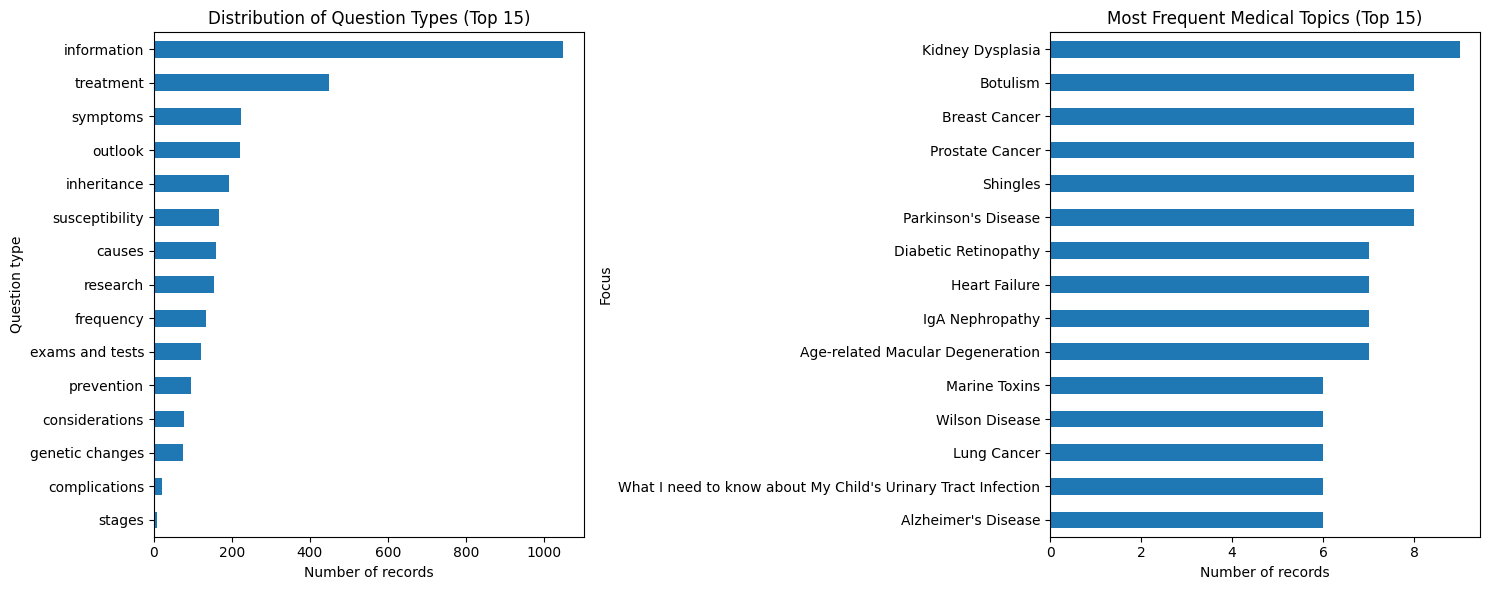


QUERY: What are the symptoms of Parkinson's disease?


,score,question,question_type,focus,source
0,1.000000,What are the symptoms of Parkinson's Disease ?,symptoms,Parkinson's Disease,NIHSeniorHealth
1,0.903809,What is (are) Parkinson's Disease ?,information,Parkinson's Disease,NIHSeniorHealth
2,0.827479,How to diagnose Parkinson's Disease ?,exams and tests,Parkinson's Disease,NIHSeniorHealth



QUERY: What are the treatments for asthma?


,score,question,question_type,focus,source
0,0.803592,How to prevent Asthma ?,prevention,Asthma,NHLBI
1,0.799315,What is (are) Asthma ?,information,Asthma,MPlusHealthTopics
2,0.743786,Who is at risk for Asthma? ?,susceptibility,Asthma,NHLBI



QUERY: What causes breast cancer?


,score,question,question_type,focus,source
0,0.849194,What is (are) Breast Cancer ?,information,Breast Cancer,NIHSeniorHealth
1,0.831459,How to prevent Breast Cancer ?,prevention,Breast Cancer,CancerGov
2,0.818227,Who is at risk for Breast Cancer? ?,susceptibility,Breast Cancer,CancerGov



QUERY: What is the outlook for heart failure?


,score,question,question_type,focus,source
0,0.932741,What is (are) Heart Failure ?,information,Heart Failure,NIHSeniorHealth
1,0.877047,Who is at risk for Heart Failure? ?,susceptibility,Heart Failure,NIHSeniorHealth
2,0.837604,What causes Heart Failure ?,causes,Heart Failure,NIHSeniorHealth



QUERY: How can stroke be prevented?


,score,question,question_type,focus,source
0,0.724231,What are the treatments for Stroke ?,treatment,Stroke,NINDS
1,0.716483,Who is at risk for Stroke? ?,susceptibility,Stroke,NIHSeniorHealth
2,0.679957,What is (are) Stroke ?,information,Stroke,NIHSeniorHealth


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

type_counts = df["question_type"].replace("", "Unknown").value_counts().head(15).sort_values()
type_counts.plot(kind="barh", ax=axes[0])
axes[0].set_title("Distribution of Question Types (Top 15)")
axes[0].set_xlabel("Number of records")
axes[0].set_ylabel("Question type")

focus_counts = df["focus"].replace("", "Unknown").value_counts().head(15).sort_values()
focus_counts.plot(kind="barh", ax=axes[1])
axes[1].set_title("Most Frequent Medical Topics (Top 15)")
axes[1].set_xlabel("Number of records")
axes[1].set_ylabel("Focus")

plt.tight_layout()
plt.show()

example_queries = [
    "What are the symptoms of Parkinson's disease?",
    "What are the treatments for asthma?",
    "What causes breast cancer?",
    "What is the outlook for heart failure?",
    "How can stroke be prevented?"
]
for query in example_queries:
    print("\nQUERY:", query)
    display(retrieve(query, top_k=3)[["score", "question", "question_type", "focus", "source"]])


## LANGKAH 8 — Batch Testing dan Evaluasi Retrieval


In [ ]:
test_queries = [
    "What are the symptoms of Parkinson's disease?",
    "What are the treatments for asthma?",
    "What causes breast cancer?",
    "What is the outlook for heart failure?",
    "How can stroke be prevented?",
    "What are the genetic changes related to cystic fibrosis?",
    "What exams and tests diagnose glaucoma?",
    "Tell me about an unrelated topic xyzqwerty987"
]

batch_rows = []
for query in test_queries:
    matches = retrieve(query, top_k=1)
    if matches.empty:
        batch_rows.append({
            "query": query, "matched_question": "", "focus": "",
            "question_type": "", "score": 0.0, "response_status": "No result"
        })
        continue
    best = matches.iloc[0]
    score = float(best["score"])
    batch_rows.append({
        "query": query,
        "matched_question": best["question"],
        "focus": best["focus"],
        "question_type": best["question_type"],
        "score": round(score, 4),
        "response_status": "Accepted by threshold" if score >= SIMILARITY_THRESHOLD else "Below threshold — uncertain"
    })

batch_results = pd.DataFrame(batch_rows)
display(batch_results)
print(f"Queries tested: {len(batch_results)}")
print(f"Accepted by threshold: {(batch_results['score'] >= SIMILARITY_THRESHOLD).sum()} / {len(batch_results)}")
print(f"Mean retrieval score: {batch_results['score'].mean():.4f}")
print("\nReminder: retrieval score is not a percentage of answer correctness.")


,query,matched_question,focus,question_type,score,response_status
0,What are the symptoms of Parkinson's disease?,What are the symptoms of Parkinson's Disease ?,Parkinson's Disease,symptoms,1.0000,Accepted by threshold
1,What are the treatments for asthma?,How to prevent Asthma ?,Asthma,prevention,0.8036,Accepted by threshold
2,What causes breast cancer?,What is (are) Breast Cancer ?,Breast Cancer,information,0.8492,Accepted by threshold
3,What is the outlook for heart failure?,What is (are) Heart Failure ?,Heart Failure,information,0.9327,Accepted by threshold
4,How can stroke be prevented?,What are the treatments for Stroke ?,Stroke,treatment,0.7242,Accepted by threshold
5,What are the genetic changes related to cystic fibrosis?,What causes Cystic Fibrosis ?,Cystic Fibrosis,causes,0.8156,Accepted by threshold
6,What exams and tests diagnose glaucoma?,What is (are) Glaucoma ?,Glaucoma,information,0.7901,Accepted by threshold
7,Tell me about an unrelated topic xyzqwerty987,Do you have information about Common Infant and Newborn Problems,Common Infant and Newborn Problems,information,0.2448,Accepted by threshold


Queries tested: 8
Accepted by threshold: 8 / 8
Mean retrieval score: 0.7700

Reminder: retrieval score is not a percentage of answer correctness.
